# Extended Ground-State and Quantum Analysis with CS and TVM

- `cs`: Carnahan-Starling
- `tvm`: truncated-virial model


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

cwd = Path.cwd().resolve()
workspace_dir = None

for candidate in [cwd / "nuclear_matter_workflows", cwd.parent / "nuclear_matter_workflows", cwd.parent, cwd]:
    if (
        (candidate / "ground_state_ab_k0" / "src" / "ground_state_ab_k0").exists()
        and (candidate / "quantum_tc_nc_scf" / "src" / "quantum_tc_nc_scf").exists()
    ):
        workspace_dir = candidate
        break

if workspace_dir is None:
    raise RuntimeError("Could not locate the workflow folder.")

ground_state_src = workspace_dir / "ground_state_ab_k0" / "src"
quantum_src = workspace_dir / "quantum_tc_nc_scf" / "src"
results_dir = workspace_dir / "results"
results_dir.mkdir(exist_ok=True)

for path in [str(ground_state_src), str(quantum_src)]:
    if path not in sys.path:
        sys.path.insert(0, path)

from ground_state_ab_k0 import DEFAULT_ALPHA_LIST as GS_ALPHA_LIST
from ground_state_ab_k0 import DEFAULT_C_LIST as GS_C_LIST
from ground_state_ab_k0.reporting import results_to_records
from ground_state_ab_k0.solver import compute_ground_state_point, compute_model_family

from quantum_tc_nc_scf import DEFAULT_ALPHA_LIST as Q_ALPHA_LIST
from quantum_tc_nc_scf import DEFAULT_C_LIST as Q_C_LIST
from quantum_tc_nc_scf.reporting import critical_results_to_records
from quantum_tc_nc_scf.solver import (
    QuantumCriticalSettings,
    compute_model_family_quantum,
    compute_quantum_critical_point,
)


## CS/TVM Thermodynamic Input

For the two added repulsive models we use the same QvdW-style attraction as in the symmetric-matter construction,

$$u(n) = -n,$$

together with a model-dependent available-volume fraction `f(n,b)` such that

$$n = f(n,b)\,n_{\mathrm{id}},$$
$$\epsilon(T=0,n) = f(n,b)\,\epsilon_{\mathrm{id}}(n_{\mathrm{id}}) - a n^2,$$
$$p(T,n) = \left[f(n,b) - n\,\partial_n f(n,b)\right] p_{\mathrm{id}}(T,n_{\mathrm{id}}) - a n^2.$$

The new excluded-volume prescriptions are

$$f_{\mathrm{CS}}(n,b)=\exp\!\left[-\frac{3bn}{4-bn}-\frac{4bn}{(4-bn)^2}\right],$$

$$f_{\mathrm{TVM}}(n,b)=\exp\!\left(-bn-\tfrac12 (bn)^2\right).$$




In [2]:
BASE_MODELS = [
    ("vdw", "VDW", None),
    ("cs", "CS", None),
    ("tvm", "TVM", None),
    ("rks", "RKS", None),
    ("pr", "PR", None),
]

MODEL_LABELS = {model: label for model, label, _ in BASE_MODELS}
MODEL_ORDER = {model: index for index, (model, _, _) in enumerate(BASE_MODELS)}
COLOR_MAP = {
    "vdw": "black",
    "cs": "tab:blue",
    "tvm": "tab:red",
    "rks": "tab:orange",
    "pr": "tab:green",
    "clausius": "magenta",
    "dieterici": "tab:purple",
}


## Part I. Ground-State `a`, `b`, and $K_0$

In [3]:
ground_base_results = [
    compute_ground_state_point(model_name, par=par)
    for model_name, _, par in BASE_MODELS
]
ground_base_results = [result for result in ground_base_results if result is not None]

ground_clausius_results = compute_model_family("clausius", GS_C_LIST)
ground_dieterici_results = compute_model_family("dieterici", GS_ALPHA_LIST)

ground_base_df = pd.DataFrame(results_to_records(ground_base_results))
ground_clausius_df = pd.DataFrame(results_to_records(ground_clausius_results, parameter_name="c"))
ground_dieterici_df = pd.DataFrame(results_to_records(ground_dieterici_results, parameter_name="alpha"))

if not ground_base_df.empty:
    ground_base_df["label"] = ground_base_df["model"].map(MODEL_LABELS)
    ground_base_df["plot_order"] = ground_base_df["model"].map(MODEL_ORDER)
    ground_base_df = ground_base_df.sort_values("plot_order").reset_index(drop=True)

ground_combined_df = pd.concat([ground_base_df, ground_clausius_df, ground_dieterici_df], ignore_index=True)

ground_base_df.to_csv(results_dir / "extended_ground_state_base.csv", index=False)
ground_clausius_df.to_csv(results_dir / "extended_ground_state_clausius.csv", index=False)
ground_dieterici_df.to_csv(results_dir / "extended_ground_state_dieterici.csv", index=False)
ground_combined_df.to_csv(results_dir / "extended_ground_state_results.csv", index=False)

display(ground_base_df[["model", "label", "a", "b", "K0", "binding", "n_sat", "p_sat"]])
display(ground_clausius_df[["parameter_value", "a", "b", "K0", "binding"]])
display(ground_dieterici_df[["parameter_value", "a", "b", "K0", "binding"]])


,model,label,a,b,K0,binding,n_sat,p_sat
0,vdw,VDW,328.923321,3.414020,762.538952,-16.0,0.16,6.942039e-07
1,cs,CS,347.017219,4.426715,601.449391,-16.0,0.16,5.475503e-07
2,tvm,TVM,349.009326,4.280134,564.221283,-16.0,0.16,-1.005522e-06
3,rks,RKS,374.124601,2.934379,517.687257,-16.0,0.16,-9.225922e-07
4,pr,PR,408.431529,2.817209,443.121464,-16.0,0.16,4.034110e-07


,parameter_value,a,b,K0,binding
0,0.000000,328.923321,3.414020,762.538952,-16.0
1,0.526667,345.853615,3.214111,648.158193,-16.0
2,1.053333,362.475851,3.017785,558.119138,-16.0
3,1.580000,378.823685,2.824791,485.945396,-16.0
4,2.106667,394.925039,2.634907,427.182075,-16.0
5,2.633333,410.803381,2.447939,378.683157,-16.0
6,3.160000,426.478658,2.263711,338.175575,-16.0
7,3.686667,441.967996,2.082068,303.983720,-16.0
8,4.213333,457.286227,1.902869,274.850293,-16.0
9,4.740000,472.446297,1.725987,249.816854,-16.0


,parameter_value,a,b,K0,binding
0,1.666667,102.651527,2.275872,249.894543,-16.0
1,1.703704,118.179413,2.448557,292.044939,-16.0
2,1.740741,135.579757,2.606026,337.735581,-16.0
3,1.777778,155.048773,2.750264,387.037979,-16.0
4,1.814815,176.801706,2.882917,440.022241,-16.0
5,1.851852,201.074567,3.005367,496.757174,-16.0
6,1.888889,228.126032,3.118778,557.310373,-16.0
7,1.925926,258.239500,3.224144,621.748301,-16.0
8,1.962963,291.725338,3.322314,690.136359,-16.0
9,2.000000,328.923321,3.414020,762.538952,-16.0


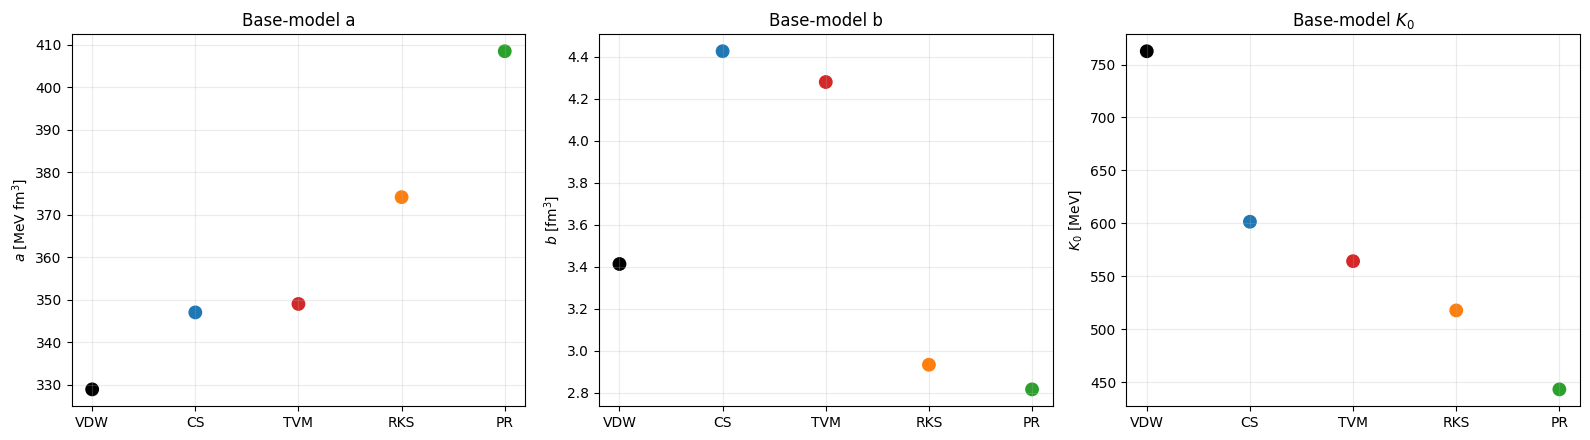

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

colors = [COLOR_MAP.get(model, "black") for model in ground_base_df["model"]]

axes[0].scatter(ground_base_df["label"], ground_base_df["a"], color=colors, s=80)
axes[0].set_title("Base-model a")
axes[0].set_ylabel(r"$a$ [MeV fm$^3$]")

axes[1].scatter(ground_base_df["label"], ground_base_df["b"], color=colors, s=80)
axes[1].set_title("Base-model b")
axes[1].set_ylabel(r"$b$ [fm$^3$]")

axes[2].scatter(ground_base_df["label"], ground_base_df["K0"], color=colors, s=80)
axes[2].set_title(r"Base-model $K_0$")
axes[2].set_ylabel(r"$K_0$ [MeV]")

for axis in axes:
    axis.grid(alpha=0.25)

fig.tight_layout()
fig.savefig(results_dir / "extended_ground_state_base_summary.png", dpi=300)
plt.show()


## Part II. Quantum $T_c$ and $n_c$ with Fermi Statistics and SCF

In [5]:
# Switch to QuantumCriticalSettings() for a denser run.
quantum_settings = QuantumCriticalSettings.quick()

quantum_base_results = [
    compute_quantum_critical_point(model_name, par=par, settings=quantum_settings)
    for model_name, _, par in BASE_MODELS
]
quantum_base_results = [result for result in quantum_base_results if result is not None]

quantum_clausius_results = compute_model_family_quantum("clausius", Q_C_LIST, settings=quantum_settings)
quantum_dieterici_results = compute_model_family_quantum("dieterici", Q_ALPHA_LIST, settings=quantum_settings)

quantum_base_df = pd.DataFrame(critical_results_to_records(quantum_base_results))
quantum_clausius_df = pd.DataFrame(critical_results_to_records(quantum_clausius_results, parameter_name="c"))
quantum_dieterici_df = pd.DataFrame(critical_results_to_records(quantum_dieterici_results, parameter_name="alpha"))

if not quantum_base_df.empty:
    quantum_base_df["label"] = quantum_base_df["model"].map(MODEL_LABELS)
    quantum_base_df["plot_order"] = quantum_base_df["model"].map(MODEL_ORDER)
    quantum_base_df = quantum_base_df.sort_values("plot_order").reset_index(drop=True)

quantum_combined_df = pd.concat([quantum_base_df, quantum_clausius_df, quantum_dieterici_df], ignore_index=True)

quantum_base_df.to_csv(results_dir / "extended_quantum_base.csv", index=False)
quantum_clausius_df.to_csv(results_dir / "extended_quantum_clausius.csv", index=False)
quantum_dieterici_df.to_csv(results_dir / "extended_quantum_dieterici.csv", index=False)
quantum_combined_df.to_csv(results_dir / "extended_quantum_results.csv", index=False)

display(quantum_base_df[["model", "label", "a", "b", "K0", "Tc", "nc", "Pc", "score"]])
display(quantum_clausius_df[["parameter_value", "a", "b", "K0", "Tc", "nc"]])
display(quantum_dieterici_df[["parameter_value", "a", "b", "K0", "Tc", "nc"]])


,model,label,a,b,K0,Tc,nc,Pc,score
0,vdw,VDW,328.923321,3.414020,762.538952,19.714052,0.072417,0.526889,1.253540e-13
1,cs,CS,347.017219,4.426715,601.449391,18.610508,0.070068,0.473071,1.311141e-13
2,tvm,TVM,349.009326,4.280134,564.221283,18.270593,0.068673,0.450182,8.266384e-14
3,rks,RKS,374.124601,2.934379,517.687257,18.240018,0.064292,0.396777,6.948462e-14
4,pr,PR,408.431529,2.817209,443.121464,17.141483,0.060724,0.331822,8.131122e-14


,parameter_value,a,b,K0,Tc,nc
0,0.000000,328.923321,3.414020,762.538952,19.714052,0.072417
1,0.526667,345.853615,3.214111,648.158193,19.134478,0.069021
2,1.053333,362.475851,3.017785,558.119138,18.621114,0.065914
3,1.580000,378.823685,2.824791,485.945396,18.162262,0.063061
4,2.106667,394.925039,2.634907,427.182075,17.748911,0.060434
5,2.633333,410.803381,2.447939,378.683157,17.374006,0.058006
6,3.160000,426.478658,2.263711,338.175575,17.031936,0.055758
7,3.686667,441.967996,2.082068,303.983720,16.718156,0.053670
8,4.213333,457.286227,1.902869,274.850293,16.428951,0.051725
9,4.740000,472.446297,1.725987,249.816854,16.161290,0.049911


,parameter_value,a,b,K0,Tc,nc
0,1.666667,102.651527,2.275872,249.894543,13.010131,0.058429
1,1.703704,118.179413,2.448557,292.044939,13.799753,0.060356
2,1.740741,135.579757,2.606026,337.735581,14.576705,0.062155
3,1.777778,155.048773,2.750264,387.037979,15.341697,0.063846
4,1.814815,176.801706,2.882917,440.022241,16.095411,0.065445
5,1.851852,201.074567,3.005367,496.757174,16.838453,0.066965
6,1.888889,228.126032,3.118778,557.310373,17.571363,0.068415
7,1.925926,258.239500,3.224144,621.748301,18.294641,0.069803
8,1.962963,291.725338,3.322314,690.136359,19.008734,0.071135
9,2.000000,328.923321,3.414020,762.538952,19.714052,0.072417


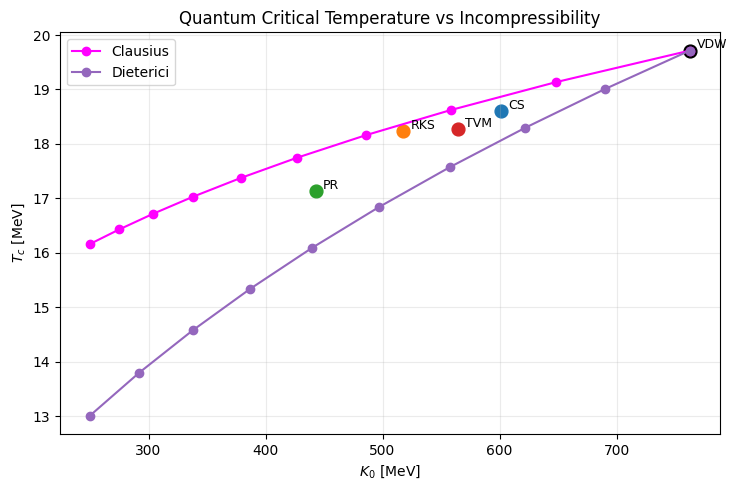

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 5))

if not quantum_clausius_df.empty:
    ax.plot(quantum_clausius_df["K0"], quantum_clausius_df["Tc"], color=COLOR_MAP["clausius"], marker="o", label="Clausius")
if not quantum_dieterici_df.empty:
    ax.plot(quantum_dieterici_df["K0"], quantum_dieterici_df["Tc"], color=COLOR_MAP["dieterici"], marker="o", label="Dieterici")

for _, row in quantum_base_df.iterrows():
    ax.scatter(row["K0"], row["Tc"], color=COLOR_MAP.get(row["model"], "black"), s=85)
    ax.text(row["K0"] + 6, row["Tc"] + 0.04, row["label"], fontsize=9)

ax.set_xlabel(r"$K_0$ [MeV]")
ax.set_ylabel(r"$T_c$ [MeV]")
ax.set_title("Quantum Critical Temperature vs Incompressibility")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(results_dir / "extended_quantum_tc_vs_k0.png", dpi=300)
plt.show()


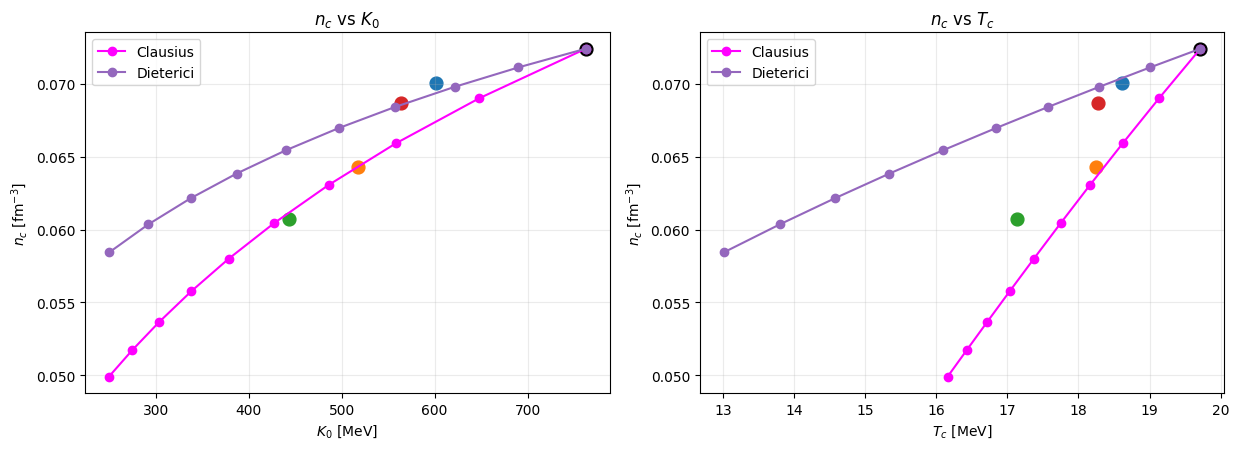

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))

if not quantum_clausius_df.empty:
    axes[0].plot(quantum_clausius_df["K0"], quantum_clausius_df["nc"], color=COLOR_MAP["clausius"], marker="o", label="Clausius")
    axes[1].plot(quantum_clausius_df["Tc"], quantum_clausius_df["nc"], color=COLOR_MAP["clausius"], marker="o", label="Clausius")
if not quantum_dieterici_df.empty:
    axes[0].plot(quantum_dieterici_df["K0"], quantum_dieterici_df["nc"], color=COLOR_MAP["dieterici"], marker="o", label="Dieterici")
    axes[1].plot(quantum_dieterici_df["Tc"], quantum_dieterici_df["nc"], color=COLOR_MAP["dieterici"], marker="o", label="Dieterici")

for _, row in quantum_base_df.iterrows():
    color = COLOR_MAP.get(row["model"], "black")
    axes[0].scatter(row["K0"], row["nc"], color=color, s=85)
    axes[1].scatter(row["Tc"], row["nc"], color=color, s=85)

axes[0].set_xlabel(r"$K_0$ [MeV]")
axes[0].set_ylabel(r"$n_c$ [fm$^{-3}$]")
axes[0].set_title(r"$n_c$ vs $K_0$")

axes[1].set_xlabel(r"$T_c$ [MeV]")
axes[1].set_ylabel(r"$n_c$ [fm$^{-3}$]")
axes[1].set_title(r"$n_c$ vs $T_c$")

for axis in axes:
    axis.grid(alpha=0.25)
    axis.legend()

fig.tight_layout()
fig.savefig(results_dir / "extended_quantum_nc_summary.png", dpi=300)
plt.show()


## Note on the Sound-Speed Section

The sound-speed workflow in the original combined notebook was intentionally left untouched. This notebook only extends the symmetric-matter ground-state and finite-temperature quantum sections with `cs` and `tvm`.